In [4]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(str(Path().resolve().parent))
import multimin as mm
import time
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters,
    surface_integral_P_X_CMND,
    trasformation_E_to_X
    )

In [5]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

c:\Users\INTERPLAY\Documents\juanita\repo\TesisRepo\density_space_mapping\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


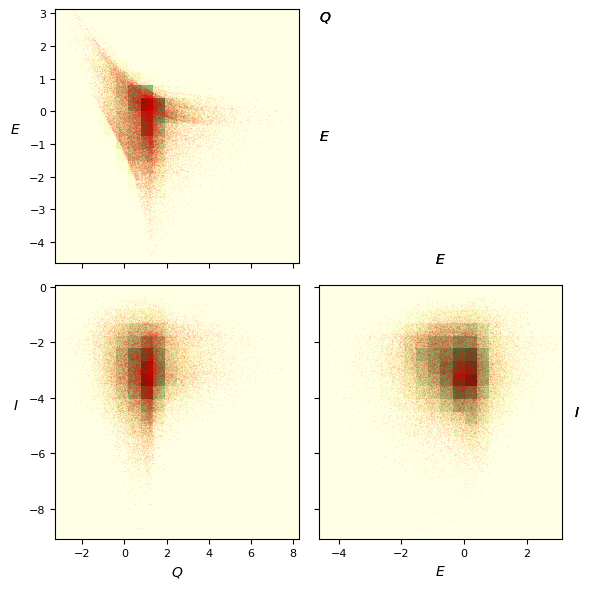

In [6]:
F = mm.FitCMND(f"../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [7]:
N = int(1e7)
fit_sample = F.cmnd.rvs(Nsam=N)

scales=[1.35,1.00,np.pi]
converted_sample = np.zeros_like(fit_sample)
for i, element in enumerate(fit_sample):
    converted_sample[i] = mm.Util.tIF(element, scales, mm.Util.u2f)

state_vectors = np.zeros((N, 6))
for el in converted_sample:
    q = el[0]
    e = el[1]
    i = el[2]
    Omega = el[3]
    w = el[4]
    M = el[5]
    a = q/(1-e)

    x, y, z, vx, vy, vz = trasformation_E_to_X(a, e, i, Omega, w, M, mu)
    state_vectors[el] = np.array([x, y, z, vx, vy, vz])

IndexError: index 3 is out of bounds for axis 0 with size 3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# TUS DATOS AQUÍ
# Reemplaza estos dos vectores con tus datos
# ==========================================
# x = posiciones_x_de_asteroides
# y = posiciones_y_de_asteroides

# EJEMPLO (BORRAR): simular 200k puntos en el cinturón interior
N = 200_000
x = np.random.normal(0, 2, N)
y = np.random.normal(0, 2, N)

# ============================
# ORBITAS PLANETARIAS (AU)
# ============================
orb_mercury = 0.39
orb_venus   = 0.72
orb_earth   = 1.00
orb_mars    = 1.52

orbits = [orb_mercury, orb_venus, orb_earth, orb_mars]
orbit_labels = ["Mercury", "Venus", "Earth", "Mars"]

# ============================
# FIGURA
# ============================
fig, ax = plt.subplots(figsize=(9,9))

# Heatmap 2D con hexbin (muy eficiente)
hb = ax.hexbin(
    x, y,
    gridsize=250,
    cmap='inferno',
    bins='log',     # escala log para ver densidades bajas y altas
    mincnt=1
)

plt.colorbar(hb, label="Log Density")

# ============================
# Dibujar órbitas planetarias
# ============================
theta = np.linspace(0, 2*np.pi, 500)
for r, label in zip(orbits, orbit_labels):
    ax.plot(r*np.cos(theta), r*np.sin(theta), lw=2, label=label)

# ============================
# Sol en el centro
# ============================
ax.scatter(0, 0, color='yellow', s=200, edgecolor='black', label='Sun', zorder=10)

# ============================
# Estética
# ============================
ax.set_aspect('equal', 'box')
ax.set_xlabel("X [AU]")
ax.set_ylabel("Y [AU]")
ax.set_title("2D Density Map of Asteroid Distribution in the Inner Solar System")

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)

plt.legend()
plt.show()


In [ ]:
#max elements
max_elements = (1.3, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 0.9
c_y = 0.9
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxy = 0.1
dz = 0.5
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxy, dxy, dz, dvxyz, dvxyz, dvxyz)

start_time = time.time()
#Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=8, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical}")
print("--- %s seconds ---" % (time.time() - start_time))

In [ ]:
# grid parameters
xmin, xmax = -1.5, 1.5
ymin, ymax = -1.5, 1.5
dx, dy = 0.1, 0.1

# generate grid lines
x_lines = np.arange(xmin, xmax + dx, dx)
y_lines = np.arange(ymin, ymax + dy, dy)

plt.figure(figsize=(6, 6))

# draw vertical lines
for x in x_lines:
    plt.plot([x, x], [ymin, ymax])

# draw horizontal lines
for y in y_lines:
    plt.plot([xmin, xmax], [y, y])

originals = [x_lines[7], y_lines[7]]
originals2 = [x_lines[8], y_lines[7]]
box = [(originals[0] - 0.1/2, originals[0] + 0.1/2), (originals[1] - 0.1/2, originals[1] + 0.1/2)]
box2 = [(originals2[0] - 0.1/2, originals2[0] + 0.1/2), (originals2[1] - 0.1/2, originals2[1] + 0.1/2)]
plt.plot(0, 0, '.', color='black', markersize=10)
plt.plot(originals[0], originals[1], '.', color='blue', markersize=10)
plt.plot(originals2[0], originals2[1], '.', color='blue', markersize=10)
plt.plot(box[0][0], y_lines[7], '.', color='green', markersize=10)
plt.plot(box[0][1], y_lines[7], '.', color='green', markersize=10)
plt.plot(box2[0][0], y_lines[7], '.', color='green', markersize=10)
plt.plot(box2[0][1], y_lines[7], '.', color='green', markersize=10)
plt.plot(x_lines[7], box[1][0], '.', color='green', markersize=10)
plt.plot(x_lines[7], box[1][1], '.', color='green', markersize=10)
plt.plot(x_lines[8], box2[1][0], '.', color='green', markersize=10)
plt.plot(x_lines[8], box2[1][1], '.', color='green', markersize=10)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Grid Centered at (0,0)")
plt.grid(False)

plt.show()

In [ ]:
xmin, xmax = 0.4, 0.8
ymin, ymax = 0.4, 0.8
dx_grid = 0.1
dy_grid = 0.1

x_vals = np.arange(xmin, xmax + dx_grid, dx_grid)
y_vals = np.arange(ymin, ymax + dy_grid, dy_grid)

NX = len(x_vals)
NY = len(y_vals)

# Storage array for results
integral_grid = np.zeros((NX, NY))

fixed_z  = 0.0
fixed_vx = 0.0
fixed_vy = (mu/1)**0.5
fixed_vz = 0.0


dx = 0.1     # width in x
dy = 0.1     # width in y
dz = 0.5
dvx = 5000 * (1/AU_m) * year
dvy = 5000 * (1/AU_m) * year
dvz = 5000 * (1/AU_m) * year

widths = (dx, dy, dz, dvx, dvy, dvz)

max_elements = (1.3, 1.0, np.pi)  # <-- fill with your values

for ix, xv in enumerate(x_vals):
    for iy, yv in enumerate(y_vals):
        vy = (mu/np.abs(xv))**0.5
        center = (xv, yv, fixed_z, fixed_vx, vy, fixed_vz)
        print("evaluating at", center)
        print("widths", widths)

        try:
            val = surface_integral_P_X_CMND(
                center=center,
                widths=widths,
                max_elements=max_elements,
                n_points=8,    
                mu=mu,
                F=F           
            )
        except Exception as err:
            print("Runtime error at center =", center)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            val = np.nan

        integral_grid[ix, iy] = val

np.savetxt("P_X_grid_3.dat", integral_grid)
# Now integral_grid[i,j] holds the integral at (x_vals[i], y_vals[j])
print("Grid computed, shape =", integral_grid.shape)


### Grid 1: 
xmin, xmax = 0.9, 1.1 

ymin, ymax = 0.9, 1.1

Runtime error at center = (np.float64(0.9), np.float64(1.2), 0.0, 0.0, np.float64(6.623941565868487), 0.0)

In [ ]:
integral_grid/(0.1*0.1)

In [ ]:
import matplotlib.pyplot as plt

with open("P_X_grid_1.dat", "rb") as f:
    integral_grid1 = np.loadtxt(f)

plt.figure(figsize=(7,6))
plt.imshow(integral_grid1.T, origin='lower',
           extent=[xmin, xmax, ymin, ymax],
           aspect='equal')
plt.colorbar(label="Integral value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Surface Integral on 2D (x,y) Grid")
plt.show()

### Grid 2: 
xmin, xmax = 1.2, 1.5 

ymin, ymax = 1.2, 1.5

In [ ]:
xmin, xmax = 1.2, 1.5
ymin, ymax = 1.2, 1.5

with open("P_X_grid_2.dat", "rb") as f:
    integral_grid2 = np.loadtxt(f)

plt.figure(figsize=(7,6))
plt.imshow(integral_grid2.T, origin='lower',
           extent=[xmin, xmax, ymin, ymax],
           aspect='equal')
plt.colorbar(label="Integral value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Surface Integral on 2D (x,y) Grid")
plt.show()

In [ ]:
integral_grid2

In [ ]:
xmin, xmax = 0.4, 0.8
ymin, ymax = 0.4, 0.8

with open("P_X_grid_3.dat", "rb") as f:
    integral_grid3 = np.loadtxt(f)

plt.figure(figsize=(7,6))
plt.imshow(integral_grid3.T, origin='lower',
           extent=[xmin, xmax, ymin, ymax],
           aspect='equal')
plt.colorbar(label="Integral value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Surface Integral on 2D (x,y) Grid")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from tqdm import tqdm # A library for a nice progress bar


# --- Define Grid and Simulation Parameters ---
# Grid range for x and y (in AU)
x_min, x_max = 1.2, 1.5
y_min, y_max = 1.2, 1.5

# The size of the integration volume for x and y
dx_cell, dy_cell = 0.1, 0.1

# "Constant" parameters for the other dimensions
z_center = 0.0
z_width = 1.0  # from -0.5 to 0.5

vx_center = 0.0
vx_width = 5000 * (1/AU_m) * year

vy_center = (mu/1)**0.5
vy_width = 5000 * (1/AU_m) * year

vz_center = 0.0
vz_width = 5000 * (1/AU_m) * year

# Other parameters for your P_X_CMND function
# (Using dummy values here, replace with your actual ones)
max_elements = (1.3, 1.0, np.pi) # a_max, e_max, i_max

# --- Create the Grid Centers ---
# We use the cell size to determine the number of steps
x_steps = int((x_max - x_min) / dx_cell) + 1
y_steps = int((y_max - y_min) / dy_cell) + 1

# Create arrays of the center points for each cell
x_centers = np.linspace(x_min, x_max, x_steps)
y_centers = np.linspace(y_min, y_max, y_steps)

# --- Initialize Results Matrix ---
probability_map = np.zeros((len(y_centers), len(x_centers)))

# --- The Main Loop ---
print("Starting probability mapping...")
# Using tqdm for a progress bar, which is helpful for long computations
for i, y_c in enumerate(tqdm(y_centers, desc="Y-axis progress")):
    for j, x_c in enumerate(x_centers):
        # Define the center and widths for this specific grid point
        vy = (mu/np.abs(x_c))**0.5

        center_6d = (x_c, y_c, z_center, vx_center, vy, vz_center)
        widths_6d = (dx_cell, dy_cell, z_width, vx_width, vy_width, vz_width)

        try:
        # Calculate the integral for this hypervolume
            prob_value = surface_integral_P_X_CMND(
                center=center_6d,
                widths=widths_6d,
                max_elements=max_elements,
                n_points=8, # Keep n_points low for speed, increase for accuracy
                mu=mu,
                F=F
            )
        except Exception as err:
            print("Runtime error at center =", center_6d)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            prob_value = np.nan

        # Store the result
        # Note: In plotting, the first index (i) corresponds to rows (y-axis)
        probability_map[i, j] = prob_value

print("Mapping complete!")

In [ ]:
x_centers

In [ ]:
np.savetxt("P_X_grid_v4.dat", probability_map)

In [ ]:
x_min, x_max

<>:28: SyntaxWarning: invalid escape sequence '\D'
<>:28: SyntaxWarning: invalid escape sequence '\D'
C:\Users\INTERPLAY\AppData\Local\Temp\ipykernel_68580\131321148.py:28: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


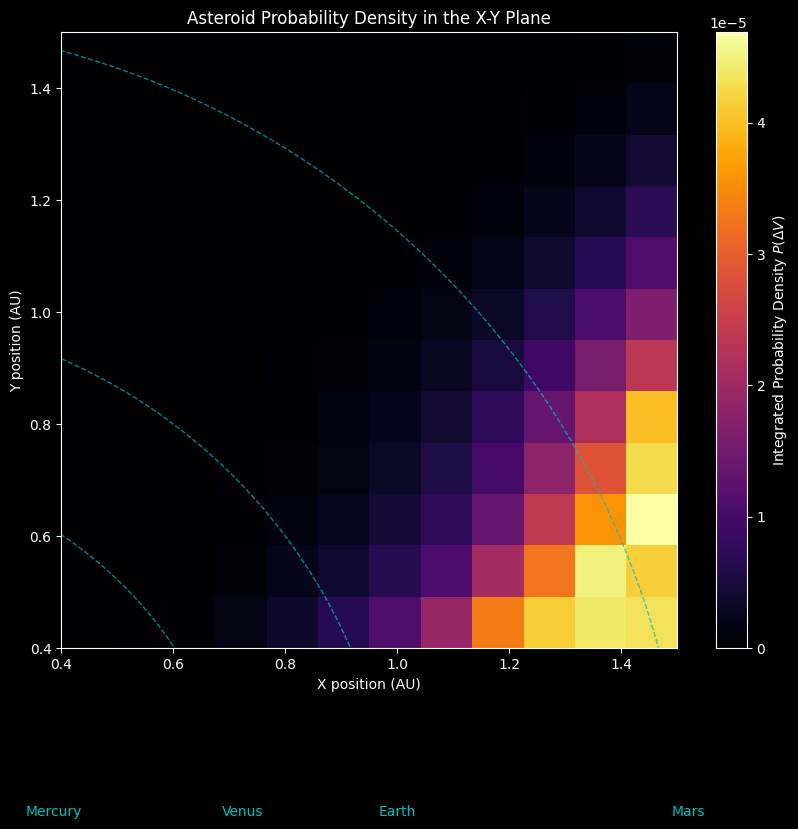

In [6]:
x_min, x_max = 0.4, 1.5
y_min, y_max = 0.4, 1.5
# ==============================================================================
# 4. VISUALIZATION
# ==============================================================================
with open("P_X_grid_v5.dat", "rb") as f:
    integral_grid = np.loadtxt(f)
# The probability values might be very small, so plotting the log can be useful
# Add a small constant to avoid log(0)
log_prob_map = np.log10(integral_grid + 1e-20) 

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

# Use imshow to create the heatmap. `origin='lower'` puts (x_min, y_min) at the bottom-left.
# `extent` correctly labels the axes with your AU values.
im = ax.imshow(
    integral_grid, 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest'
)

# Add a colorbar to show the scale
cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')
#cbar.set_label('Log10 of Integrated Probability Density') # Use if plotting log

# Add labels and title
ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') # Ensure x and y axes have the same scale

# Add orbits of planets for context
def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

plt.show()

In [5]:
integral_grid

array([[1.05463237e-14, 2.80583071e-15, 5.87182440e-16, 1.31310642e-16,
        4.68900089e-17, 1.22454243e-17, 6.80497051e-19, 7.82230873e-23,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.32763918e-14, 7.19178911e-15, 1.80054335e-15, 4.12536558e-16,
        1.25630432e-16, 4.42603926e-17, 6.41790291e-18, 4.40231768e-20,
        2.70380619e-33, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.64644351e-14, 1.61184259e-14, 4.58035123e-15, 1.19556724e-15,
        3.51405473e-16, 1.34103997e-16, 3.56335007e-17, 1.68981359e-18,
        5.61067722e-23, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==============================================================================
# 1. DEFINE GRID PARAMETERS (same as your main script)
# ==============================================================================

# Grid range for x and y (in AU)
x_min, x_max = 0.4, 1.5
y_min, y_max = 0.4, 1.5

# The size of the integration volume for x and y
dx_cell, dy_cell = 0.1, 0.1

# ==============================================================================
# 2. CREATE THE GRID CENTERS (same as your main script)
# ==============================================================================

# We use the cell size to determine the number of steps
# We add a small epsilon to avoid floating point issues at the edges
x_steps = int(round((x_max - x_min) / dx_cell)) + 1
y_steps = int(round((y_max - y_min) / dy_cell)) + 1

# Create arrays of the center points for each cell
x_centers = np.linspace(x_min, x_max, x_steps)
y_centers = np.linspace(y_min, y_max, y_steps)

# Create a meshgrid of centers, which is useful for plotting
X_centers, Y_centers = np.meshgrid(x_centers, y_centers)

# ==============================================================================
# 3. VISUALIZATION
# ==============================================================================

print(f"Grid Dimensions: {len(x_centers)} x {len(y_centers)} = {len(x_centers) * len(y_centers)} cells")

# --- Set up the plot ---
plt.style.use('default') # Using a light theme for better clarity of grid lines
fig, ax = plt.subplots(figsize=(10, 10))

# --- Draw Grid Cells ---
for x_c in x_centers:
    for y_c in y_centers:
        # Calculate the bottom-left corner of the rectangle
        bottom_left_x = x_c - dx_cell / 2
        bottom_left_y = y_c - dy_cell / 2
        
        # Create a Rectangle patch
        rect = patches.Rectangle(
            (bottom_left_x, bottom_left_y),
            dx_cell,
            dy_cell,
            linewidth=1,
            edgecolor='gray',
            facecolor='none',
            alpha=0.75
        )
        
        # Add the patch to the Axes
        ax.add_patch(rect)

# --- Plot the Center Points ---
# Plotting the centers on top of the grid cells
ax.scatter(X_centers, Y_centers, color='red', s=10, zorder=5, label='Integration Centers (x, y)')

# --- Add Context and Labels ---
# Add a point for the Sun
ax.plot(0, 0, 'o', color='yellow', markersize=15, label='Sun')

# Function to add planetary orbits for context
def plot_orbit(radius, label, color='c'):
    circle = plt.Circle((0, 0), radius, color=color, fill=False, linestyle='--', alpha=0.9, linewidth=1.5)
    ax.add_artist(circle)
    # Adjust text position for clarity
    ax.text(0, radius + 0.02, label, color=color, ha='center', va='bottom', fontsize=9)

plot_orbit(0.387, 'Mercury', 'sandybrown')
plot_orbit(0.723, 'Venus', 'navajowhite')
plot_orbit(1.0, 'Earth', 'deepskyblue')
plot_orbit(1.52, 'Mars', 'firebrick')


# --- Final Plot Adjustments ---
ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Visualization of the Integration Grid')

# Set the limits to be slightly larger than the grid to see it clearly
ax.set_xlim(x_min - dx_cell, x_max + dx_cell)
ax.set_ylim(y_min - dy_cell, y_max + dy_cell)

ax.set_aspect('equal', adjustable='box') # Crucial for correct visualization of circles and squares
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend()

plt.show()

In [9]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import multimin as mm
from tqdm import tqdm
from utils.Utils import (
    trasformation_X_to_E,
    Jacobian_qei_to_QEI,
    compute_jacobian_XoE,
    P_E_CMND
    )

In [10]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        #print("evaluating point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        q = a*(1-e)

        if q > 1.3 or e > 1: 
             P.flat[idx] = 0
        else:
            J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
            J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
            with np.errstate(divide='ignore', invalid='ignore'):
                det = np.linalg.det(J)
                det_QEI = np.linalg.det(J_qei_to_QEI)
                #print(x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx])
                #print(det)
                if det == 0 or not np.isfinite(det):
                    print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    #print(P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_AEI)) 
                    P.flat[idx] = P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)
                
    return P.reshape(shape)

In [11]:
def surface_integral_P_X_CMND(center, widths, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        max_elemetns: tuple/list/array of (a_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()
    # Evaluate P at all points
    Pf = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    #return integral, y_points
    return integral

In [12]:
# --- Define Grid and Simulation Parameters ---
# Grid range for x and y (in AU)
x_min, x_max = -1.5, 0.4
y_min, y_max = 0.4, 1.5

# The size of the integration volume for x and y
dx_cell, dy_cell = 0.1, 0.1

# "Constant" parameters for the other dimensions
z_center = 0.0
z_width = 1.0  # from -0.5 to 0.5

vx_center = 0.0
vx_width = 5000 * (1/AU_m) * year

vy_center = (mu/1)**0.5
vy_width = 5000 * (1/AU_m) * year

vz_center = 0.0
vz_width = 5000 * (1/AU_m) * year

# Other parameters for your P_X_CMND function
# (Using dummy values here, replace with your actual ones)
max_elements = (1.3, 1.0, np.pi) # a_max, e_max, i_max

# --- Create the Grid Centers ---
# We use the cell size to determine the number of steps
x_steps = int((x_max - x_min) / dx_cell) + 1
y_steps = int((y_max - y_min) / dy_cell) + 1

# Create arrays of the center points for each cell
x_centers = np.linspace(x_min, x_max, x_steps)
y_centers = np.linspace(y_min, y_max, y_steps)

# --- Initialize Results Matrix ---
probability_map = np.zeros((len(y_centers), len(x_centers)))

# --- The Main Loop ---
print("Starting probability mapping...")
# Using tqdm for a progress bar, which is helpful for long computations
for i, y_c in enumerate(tqdm(y_centers, desc="Y-axis progress")):
    for j, x_c in enumerate(x_centers):
        # Define the center and widths for this specific grid point
        vy = (mu/np.abs(x_c))**0.5

        center_6d = (x_c, y_c, z_center, vx_center, vy, vz_center)
        widths_6d = (dx_cell, dy_cell, z_width, vx_width, vy_width, vz_width)

        try:
        # Calculate the integral for this hypervolume
            prob_value = surface_integral_P_X_CMND(
                center=center_6d,
                widths=widths_6d,
                max_elements=max_elements,
                n_points=8, # Keep n_points low for speed, increase for accuracy
                mu=mu,
                F=F
            )
        except Exception as err:
            print("Runtime error at center =", center_6d)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            prob_value = np.nan

        # Store the result
        # Note: In plotting, the first index (i) corresponds to rows (y-axis)
        probability_map[i, j] = prob_value

print("Mapping complete!")
np.savetxt("P_X_grid_v8.dat", probability_map)

Starting probability mapping...


Y-axis progress: 100%|██████████| 12/12 [5:36:09<00:00, 1680.82s/it] 

Mapping complete!


In [ ]:
np.savetxt("P_X_grid_v7.dat", probability_map)

In [9]:
x_min, x_max = -1.5, -0.4
y_min, y_max = 0.4, 1.5

<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
C:\Users\INTERPLAY\AppData\Local\Temp\ipykernel_70416\1014841377.py:26: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


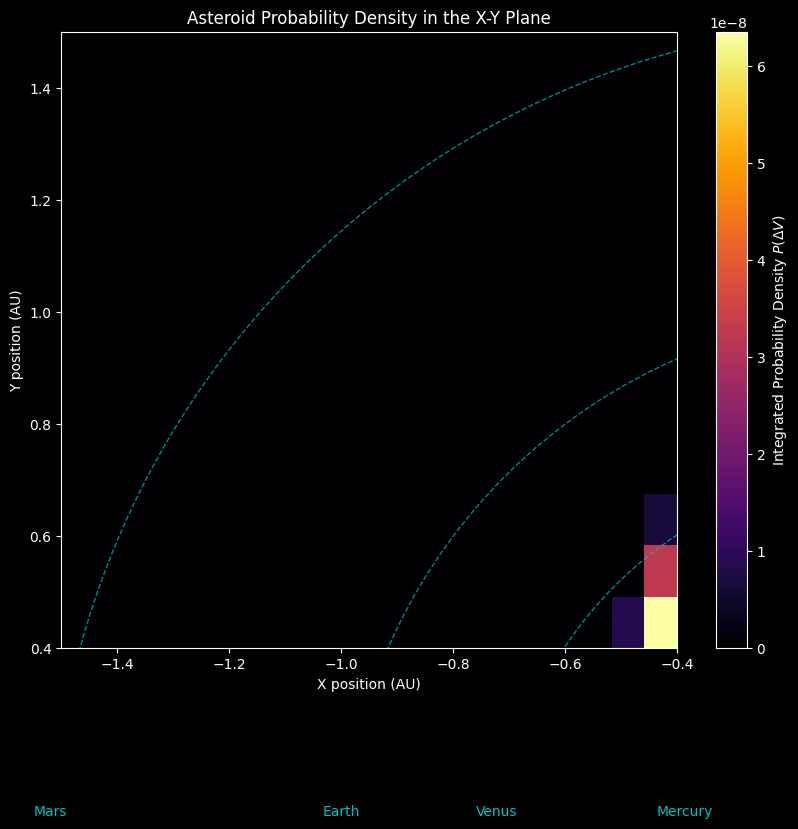

In [10]:
# ==============================================================================
# 4. VISUALIZATION
# ==============================================================================
with open("P_X_grid_v8.dat", "rb") as f:
    integral_grid = np.loadtxt(f)
# The probability values might be very small, so plotting the log can be useful
# Add a small constant to avoid log(0)
log_prob_map = np.log10(integral_grid + 1e-20) 

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

# Use imshow to create the heatmap. `origin='lower'` puts (x_min, y_min) at the bottom-left.
# `extent` correctly labels the axes with your AU values.
im = ax.imshow(
    integral_grid, 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest'
)

# Add a colorbar to show the scale
cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')
#cbar.set_label('Log10 of Integrated Probability Density') # Use if plotting log

# Add labels and title
ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') # Ensure x and y axes have the same scale

# Add orbits of planets for context
def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(-radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')
plt.show()

In [ ]:
integral_grid[np.isnan(integral_grid)]